In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_parquet('../../data/AAPL.parquet')

In [30]:
df.shape

(3769, 31)

In [31]:
df.head()

,date,open,high,low,close,volume,dividends,stock splits,ticker,company_name,...,macd_signal,atr_14,volatility_20d,volume_sma_20,volume_ratio,high_52w,low_52w,bb_middle,bb_upper,bb_lower
0,2011-02-23 00:00:00-05:00,10.150564,10.326446,10.145769,10.265922,671854400,0.0,0.0,AAPL,Apple Inc.,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-02-24 00:00:00-05:00,10.307876,10.341733,10.138584,10.273717,499900800,0.0,0.0,AAPL,Apple Inc.,...,0.000124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-02-25 00:00:00-05:00,10.345030,10.440013,10.331247,10.431923,380018800,0.0,0.0,AAPL,Apple Inc.,...,0.002844,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-02-28 00:00:00-05:00,10.524207,10.638365,10.520611,10.583234,403074000,0.0,0.0,AAPL,Apple Inc.,...,0.009455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011-03-01 00:00:00-05:00,10.650949,10.658439,10.417537,10.466376,456136800,0.0,0.0,AAPL,Apple Inc.,...,0.016273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df.dtypes

date               object
open              float64
high              float64
low               float64
close             float64
volume              int64
dividends         float64
stock splits      float64
ticker             object
company_name       object
sector             object
return_1d         float64
return_5d         float64
return_20d        float64
log_return        float64
sma_20            float64
sma_50            float64
sma_200           float64
ema_12            float64
rsi_14            float64
macd              float64
macd_signal       float64
atr_14            float64
volatility_20d    float64
volume_sma_20     float64
volume_ratio      float64
high_52w          float64
low_52w           float64
bb_middle         float64
bb_upper          float64
bb_lower          float64
dtype: object

In [33]:
df = pd.read_parquet('../../data/aapl.parquet')
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.sort_values('date')
df_plot = df[df['date'] >= pd.Timestamp('2022-01-01', tz='UTC')].copy()

Using plotly for visualization -  Interactive

In [34]:
import plotly.graph_objects as go
from IPython.display import HTML

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_plot['date'],
    y=df_plot['return_1d'],
    mode='lines',
    name='Daily Return',
    line=dict(color='steelblue', width=1)
))
fig.add_hline(y=0, line_color='red', line_dash='dash', line_width=1)
fig.update_layout(
    title='AAPL — Daily Returns (2022-present)',
    xaxis_title='Date',
    yaxis_title='1-Day Return',
    template='plotly_white',
    height=400
)
HTML(fig.to_html(include_plotlyjs='cdn'))

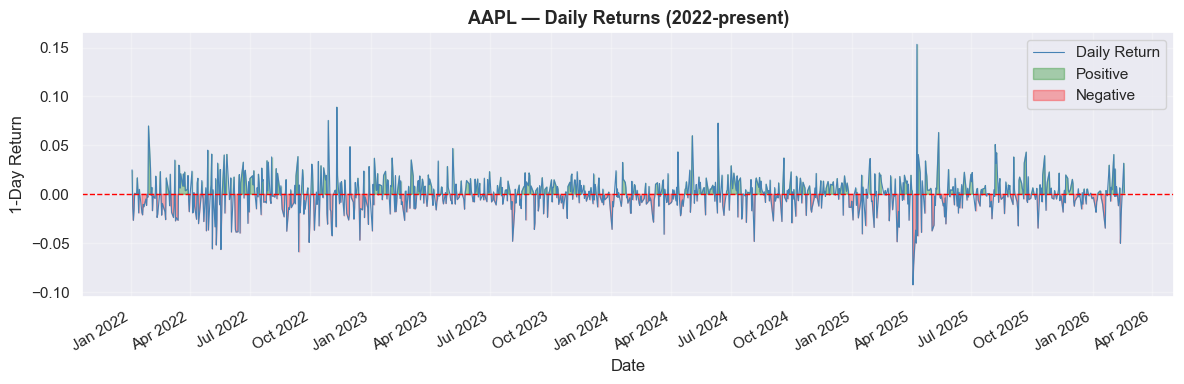

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_plot['date'], df_plot['return_1d'],
        color='steelblue', linewidth=0.8, label='Daily Return')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.fill_between(df_plot['date'], df_plot['return_1d'], 0,
                where=(df_plot['return_1d'] >= 0), color='green', alpha=0.3, label='Positive')
ax.fill_between(df_plot['date'], df_plot['return_1d'], 0,
                where=(df_plot['return_1d'] < 0),  color='red',   alpha=0.3, label='Negative')
ax.set_title('AAPL — Daily Returns (2022-present)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('1-Day Return')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

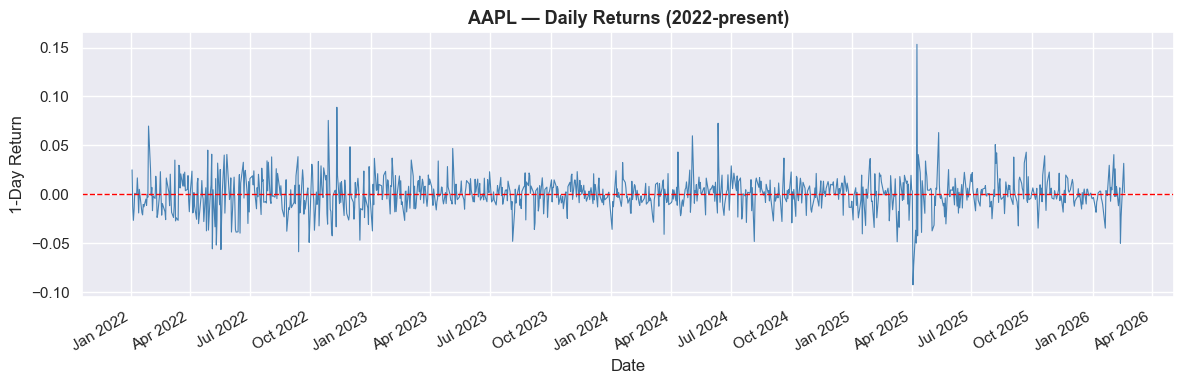

In [36]:
import seaborn as sns

sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=df_plot, x='date', y='return_1d',
             color='steelblue', linewidth=0.8, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('AAPL — Daily Returns (2022-present)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('1-Day Return')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()